# BABA Stock Prediction — Demo completo da Fase 2 do desafio

Notebook narrado da pipeline inteira do Tech Challenge Fase 4 — MLET pós-graduação.

Cobertura do enunciado (`plan/plan.md`):

- **1 — Coleta e pré-processamento dos dados** (yfinance → Parquet, MinMaxScaler, janelas).
- **2 — Desenvolvimento do modelo LSTM** (arquitetura, treino, avaliação).
- **3 — Salvamento do modelo** (`.keras` + scaler).
- **4 — Deploy (referência)** — código vive em `src/api/` e é containerizado via `Dockerfile`+`docker-compose.yml`; demonstrado fora deste notebook.
- **5 — Escalabilidade e monitoramento** — MLflow + middleware de logs (referência).

Este notebook **importa** as mesmas funções usadas pelo pipeline de produção em `src/model/` em vez de duplicá-las.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import DATA, MODEL, RAW_PARQUET, MODEL_PATH, SCALER_PATH
from src.data.fetch import fetch
from src.data.preprocess import build_splits
from src.model.architecture import build_lstm
from src.model.evaluate import all_metrics

print(f'Symbol: {DATA.symbol} · Lookback: {MODEL.lookback} dias · Target: {DATA.target_col}')

Symbol: BABA · Lookback: 60 dias · Target: Close


## Fase 1.1 — Coleta de dados

Histórico OHLCV diário da BABA via `yfinance`, salvo em Parquet. Idempotente — não baixa de novo se o arquivo já existe.

In [2]:
if not RAW_PARQUET.exists():
    fetch()
df = pd.read_parquet(RAW_PARQUET).set_index('Date').sort_index()
print(f'{len(df)} dias de pregão · {df.index.min().date()} → {df.index.max().date()}')
df.head()

2859 dias de pregão · 2015-01-02 → 2026-05-15


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,98.388405,103.599998,104.720001,102.519997,104.239998,12303400
2015-01-05,95.919189,101.000000,103.019997,99.900002,102.760002,18337000
2015-01-06,98.122482,103.320000,103.849998,100.110001,101.250000,15720400
2015-01-07,96.992348,102.129997,104.739998,102.029999,104.589996,11052200
2015-01-08,99.746475,105.029999,105.339996,102.680000,102.949997,12942100


## EDA — Preço e volume

Visualização rápida da série. BABA tem três regimes claros: crescimento até 2020, crash regulatório 2021-22, recuperação parcial daí em diante.

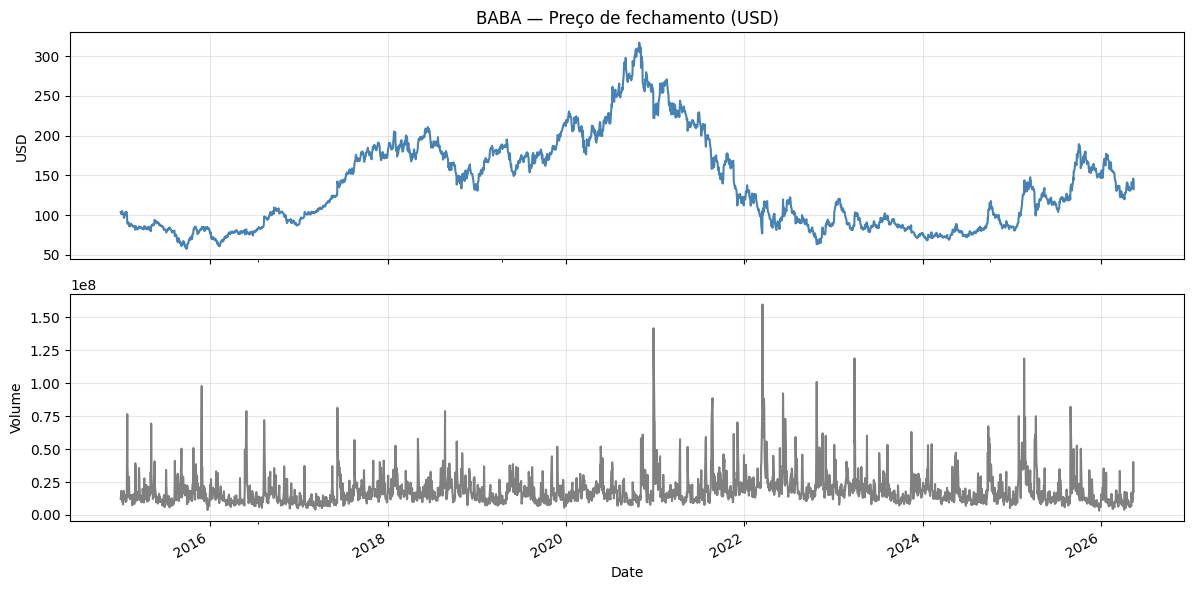

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
df['Close'].plot(ax=ax1, color='steelblue')
ax1.set_title(f'{DATA.symbol} — Preço de fechamento (USD)')
ax1.set_ylabel('USD'); ax1.grid(alpha=0.3)
df['Volume'].plot(ax=ax2, color='gray')
ax2.set_ylabel('Volume'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## EDA — Retornos diários (estacionariedade)

Preço é não-estacionário. Retornos diários (variação percentual) ficam próximos de estacionários, oscilando em torno de zero — propriedade importante pra modelos estatísticos.

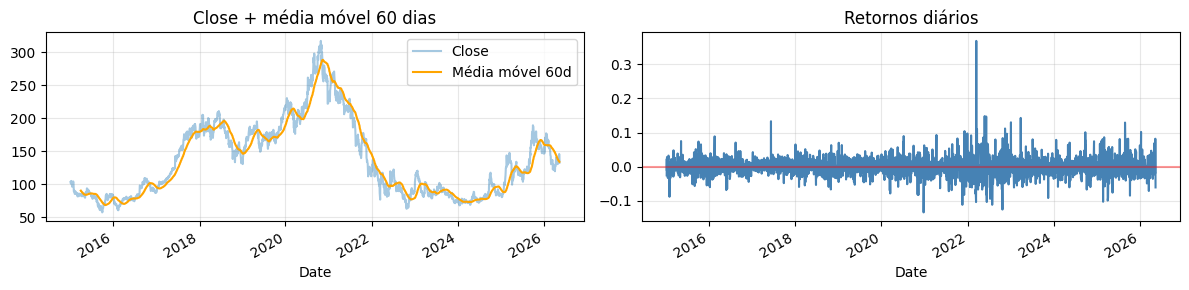

Retorno médio: 0.0438%  ·  Std: 2.6743%


In [4]:
rets = df['Close'].pct_change().dropna()
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
df['Close'].plot(ax=ax[0], alpha=0.4, label='Close')
df['Close'].rolling(60).mean().plot(ax=ax[0], label='Média móvel 60d', color='orange')
ax[0].legend(); ax[0].set_title('Close + média móvel 60 dias'); ax[0].grid(alpha=0.3)
rets.plot(ax=ax[1], color='steelblue')
ax[1].set_title('Retornos diários'); ax[1].axhline(0, color='red', alpha=0.4); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Retorno médio: {rets.mean():.4%}  ·  Std: {rets.std():.4%}')

## Baseline ingênuo — "preço de amanhã = preço de hoje"

Régua mínima de comparação. Qualquer modelo precisa, no mínimo, ficar perto desse baseline em MAE/RMSE/MAPE.

In [5]:
close = df['Close'].values
naive_metrics = all_metrics(close[1:], close[:-1])
print('Naive baseline (y_hat = y_{t-1}):')
for k, v in naive_metrics.items():
    unit = '%' if k == 'mape' else 'USD'
    print(f'  {k.upper():5s} = {v:7.3f} {unit}')

Naive baseline (y_hat = y_{t-1}):
  MAE   =   2.484 USD
  RMSE  =   3.688 USD
  MAPE  =   1.845 %


## Fase 1.2 — Pré-processamento

- `MinMaxScaler` para o intervalo `[0, 1]`, **fitado apenas no treino** (evita data leakage).
- Split cronológico **70 / 15 / 15** (treino / validação / teste).
- Janelas deslizantes de `lookback = 60` dias → cada exemplo tem shape `(60, 1)`.

Tudo isso vive em `src/data/preprocess.py:build_splits()`.

In [6]:
splits = build_splits(df=df.reset_index(), lookback=MODEL.lookback)
scaler = splits.scaler
print(f'Shapes (samples, lookback, features):')
print(f'  X_train: {splits.X_train.shape}  ·  y_train: {splits.y_train.shape}')
print(f'  X_val:   {splits.X_val.shape}  ·  y_val:   {splits.y_val.shape}')
print(f'  X_test:  {splits.X_test.shape}  ·  y_test:  {splits.y_test.shape}')
print(f'\nMinMaxScaler: feature_range={scaler.feature_range}  ·  data_min={scaler.data_min_[0]:.2f}  ·  data_max={scaler.data_max_[0]:.2f}')

2026-05-18 22:35:45,667 INFO Shapes — train (1941, 60, 1) val (428, 60, 1) test (430, 60, 1)


Shapes (samples, lookback, features):
  X_train: (1941, 60, 1)  ·  y_train: (1941,)
  X_val:   (428, 60, 1)  ·  y_val:   (428,)
  X_test:  (430, 60, 1)  ·  y_test:  (430,)

MinMaxScaler: feature_range=(0, 1)  ·  data_min=57.39  ·  data_max=317.14


## Fase 2.1 — Construção do modelo LSTM

Arquitetura definida em `src/model/architecture.py:build_lstm()`:

```
Input(60, 1)
  → LSTM(50, return_sequences=True) → Dropout(0.2)
  → LSTM(50)                        → Dropout(0.2)
  → Dense(1)
```

Compilada com `Adam(lr=1e-3)` + perda `MSE` + métrica `MAE`.

In [7]:
import tensorflow as tf
tf.keras.utils.set_random_seed(MODEL.random_seed)

model = build_lstm()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Fase 2.2 — Treinamento

Treina o modelo de verdade — ~30 épocas, ~1 minuto em CPU.

Callbacks:
- **`EarlyStopping(patience=10)`** — para quando `val_loss` não melhorar por 10 épocas.
- **`ModelCheckpoint`** — salva o melhor modelo no disco em `models/lstm_baba.keras`.

(Para o pipeline com tracking automático no MLflow, use `python -m src.model.train` no terminal — é o que registra runs no `./mlruns/`.)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=MODEL.early_stop_patience, restore_best_weights=True),
    ModelCheckpoint(filepath=str(MODEL_PATH), monitor='val_loss', save_best_only=True),
]

history = model.fit(
    splits.X_train, splits.y_train,
    validation_data=(splits.X_val, splits.y_val),
    epochs=MODEL.epochs,
    batch_size=MODEL.batch_size,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/50


61/61 - 2s - 36ms/step - loss: 0.0157 - mae: 0.0806 - val_loss: 4.2155e-04 - val_mae: 0.0147


Epoch 2/50


61/61 - 1s - 13ms/step - loss: 0.0030 - mae: 0.0393 - val_loss: 4.0785e-04 - val_mae: 0.0151


Epoch 3/50


...

61/61 - 1s - 12ms/step - loss: 8.6855e-04 - mae: 0.0215 - val_loss: 1.9382e-04 - val_mae: 0.0103


Epoch 49/50


61/61 - 1s - 12ms/step - loss: 9.0307e-04 - mae: 0.0218 - val_loss: 1.4040e-04 - val_mae: 0.0085


Epoch 50/50


61/61 - 1s - 13ms/step - loss: 8.9973e-04 - mae: 0.0216 - val_loss: 1.3134e-04 - val_mae: 0.0086


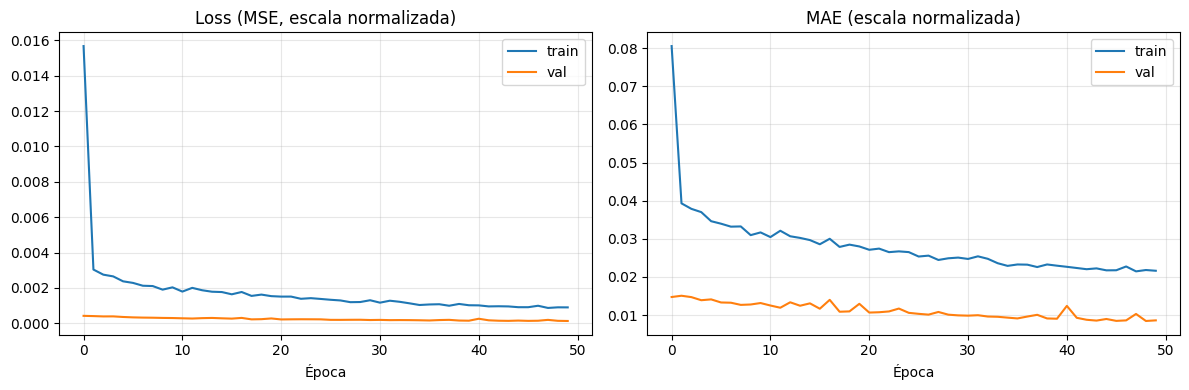

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Loss (MSE, escala normalizada)')
ax[0].set_xlabel('Época'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history.history['mae'], label='train')
ax[1].plot(history.history['val_mae'], label='val')
ax[1].set_title('MAE (escala normalizada)')
ax[1].set_xlabel('Época'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Fase 2.3 — Avaliação no conjunto de teste

Previsões são des-escaladas (inverse_transform) e métricas calculadas em **dólares** — diretamente interpretáveis.

Métricas vêm de `src/model/evaluate.py:all_metrics()`.

In [10]:
y_pred_scaled = model.predict(splits.X_test, verbose=0).ravel()
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true = scaler.inverse_transform(splits.y_test.reshape(-1, 1)).ravel()

metrics = all_metrics(y_true, y_pred)
print('Métricas no conjunto de teste (escala original em USD):')
for k, v in metrics.items():
    unit = '%' if k == 'mape' else 'USD'
    print(f'  {k.upper():5s} = {v:7.3f} {unit}')

print('\nComparação com baseline ingênuo:')
for k in metrics:
    delta = metrics[k] - naive_metrics[k]
    sign = '↓ melhor' if delta < 0 else '↑ pior'
    unit = '%' if k == 'mape' else 'USD'
    print(f'  {k.upper():5s}  LSTM {metrics[k]:7.3f} vs naive {naive_metrics[k]:7.3f}  ({delta:+.3f} {unit} {sign})')

Métricas no conjunto de teste (escala original em USD):
  MAE   =   3.749 USD
  RMSE  =   5.043 USD
  MAPE  =   2.943 %

Comparação com baseline ingênuo:
  MAE    LSTM   3.749 vs naive   2.484  (+1.265 USD ↑ pior)
  RMSE   LSTM   5.043 vs naive   3.688  (+1.355 USD ↑ pior)
  MAPE   LSTM   2.943 vs naive   1.845  (+1.099 % ↑ pior)


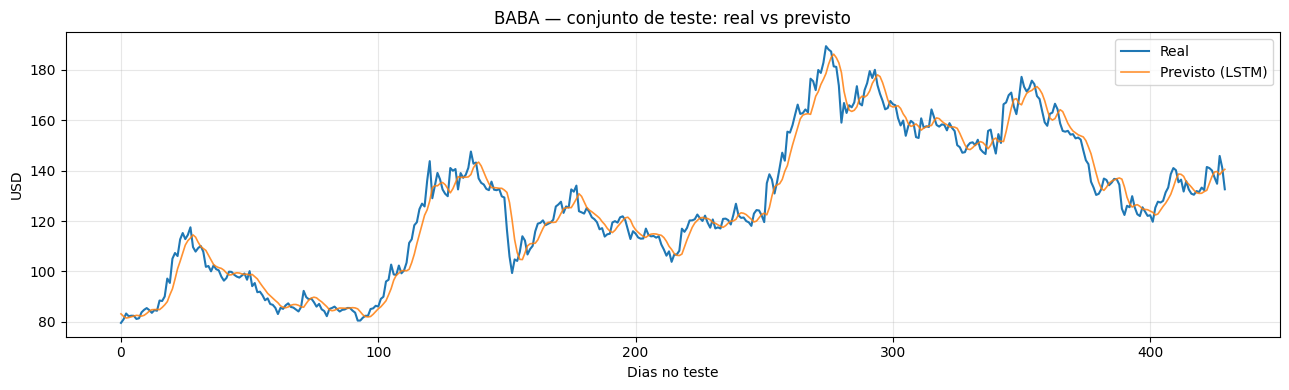

In [11]:
plt.figure(figsize=(13, 4))
plt.plot(y_true, label='Real', linewidth=1.5)
plt.plot(y_pred, label='Previsto (LSTM)', alpha=0.85, linewidth=1.2)
plt.title(f'{DATA.symbol} — conjunto de teste: real vs previsto')
plt.ylabel('USD'); plt.xlabel('Dias no teste')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Fase 3 — Salvamento do modelo

Dois artefatos persistidos em `models/`:

- **`lstm_baba.keras`** — pesos + arquitetura em formato nativo do Keras v3 (substituto recomendado do `.h5`).
- **`scaler.pkl`** — `MinMaxScaler` fitado, serializado com `joblib`. Necessário pra des-escalar previsões em produção.

(O `ModelCheckpoint` já salvou a melhor versão durante o treino; aqui apenas confirmamos e gravamos o scaler.)

In [12]:
import joblib

model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f'Modelo salvo: {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024:.1f} KB)')
print(f'Scaler salvo: {SCALER_PATH}  ({SCALER_PATH.stat().st_size / 1024:.1f} KB)')

Modelo salvo: C:\Users\vitor\Documents\POS\4\baba-stock-prediction\models\lstm_baba.keras  (395.0 KB)
Scaler salvo: C:\Users\vitor\Documents\POS\4\baba-stock-prediction\models\scaler.pkl  (0.7 KB)


## Fase 4 — Deploy (referência)

A API REST que serve este modelo vive em `src/api/` (`main.py`, `schemas.py`, `inference.py`, `middleware.py`).

Endpoints expostos:

| Método | Rota              | O que faz |
|--------|-------------------|-----------|
| GET    | `/health`         | Healthcheck — confirma que o modelo está carregado. |
| POST   | `/predict`        | Recebe 60 fechamentos, devolve o próximo previsto. |
| POST   | `/predict/latest` | Busca os últimos 60 dias no Yahoo Finance e prevê o próximo. |
| GET    | `/metrics`        | Contadores + percentis de latência (p50/p95/p99). |

Para rodar local:

```bash
uvicorn src.api.main:app --reload
# → http://localhost:8000/docs
```

Também há `Dockerfile` + `docker-compose.yml` na raiz pra subir o stack inteiro (API + MLflow server) com `docker compose up`.

## Fase 5 — Escalabilidade e monitoramento (referência)

**Treino:** todo `python -m src.model.train` registra um run no MLflow (`./mlruns/`) com hiperparâmetros, métricas por época, métricas de teste e o modelo como artefato. Para visualizar:

```bash
mlflow ui --backend-store-uri ./mlruns --port 5050
# → http://localhost:5050
```

**Serving:** middleware em `src/api/middleware.py` emite uma linha JSON estruturada por requisição e alimenta um ring buffer de 1.000 latências, exposto em `GET /metrics`.

---

**Fim do demo.** Para o roteiro completo de gravação do vídeo de defesa, ver [`plan/demo_script.md`](../plan/demo_script.md).